get data

In [11]:
import requests
from lxml import html
import pandas as pd
url = 'https://open.dosm.gov.my/dashboard/producer-prices'
url2 = 'https://open.dosm.gov.my/dashboard/consumer-prices'
session = requests.session()
r =session.get(url)
r2 =session.get(url2)


tree = html.fromstring(r.content)
tree2 = html.fromstring(r2.content)
url = "https://storage.data.gov.my/commodities/fuelprice.parquet"

df = pd.read_parquet(url)

FUEL

In [4]:
df["date"] = pd.to_datetime(df["date"])

# columns to calculate MoM for
df["date"] = pd.to_datetime(df["date"])

price_cols = [
    "ron95",
    "ron97",
    "diesel",
    "diesel_eastmsia",
    "ron95_budi95",
    "ron95_skps",
]

fuel_level = df[df["series_type"].eq("level")].copy()

monthly_level = (
    fuel_level
    .sort_values("date")
    .set_index("date")[price_cols]
    .resample("ME")
    .last()
)

mom_pct = monthly_level.pct_change() * 100

/tmp/ipykernel_2757719/2524481142.py:25: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  mom_pct = monthly_level.pct_change() * 100


PPI

In [5]:
import json
import pandas as pd

js = json.loads(tree.xpath('//script[@id="__NEXT_DATA__"]')[0].text)
growth = js['props']['pageProps']['timeseries']['data']['growth_mom']
time = growth['x']
ppi = growth['overall']

ppi = pd.DataFrame(
    {"ppi": ppi},
    index=pd.to_datetime(time, unit="ms")
)

print(ppi.head())

              ppi
2010-02-01  0.000
2010-03-01  1.524
2010-04-01 -0.100
2010-05-01 -1.202
2010-06-01  0.406


CPI

                 cpi
1980-02-01  0.497512
1980-03-01  0.000000
1980-04-01 -0.495050
1980-05-01  0.995025
1980-06-01  0.985222


<Axes: >

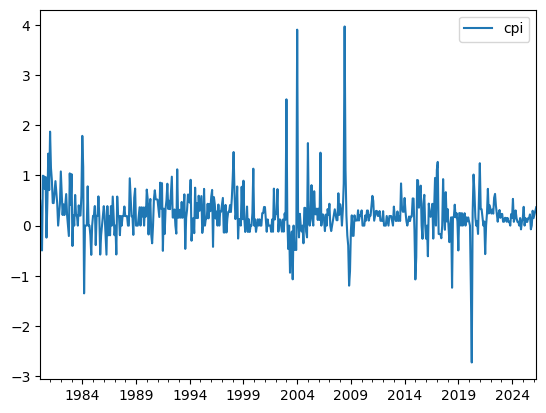

In [32]:
import json
import pandas as pd

js = json.loads(tree2.xpath('//script[@id="__NEXT_DATA__"]')[0].text)
growth = js['props']['pageProps']['timeseries']['data']['headline']['growth_mom']

time = growth['x']
cpi = growth['00']

cpi = pd.DataFrame(
    {"cpi": cpi},
    index=pd.to_datetime(time, unit="ms")
)

print(cpi.head())
cpi.plot()

In [35]:
ppi_plot = ppi.copy()
ppi_plot["month"] = ppi_plot.index.to_period("M")

cpi_plot = cpi.copy()
cpi_plot["month"] = cpi_plot.index.to_period("M")

fuel_plot = mom_pct.copy()
fuel_plot["month"] = fuel_plot.index.to_period("M")

plot_df = fuel_plot.merge(
    ppi_plot[["month", "ppi"]],
    on="month",
    how="inner"
).set_index("month")


plot_df = plot_df.merge(
    cpi_plot[["month", "cpi"]],
    on="month",
    how="inner"
).set_index("month")


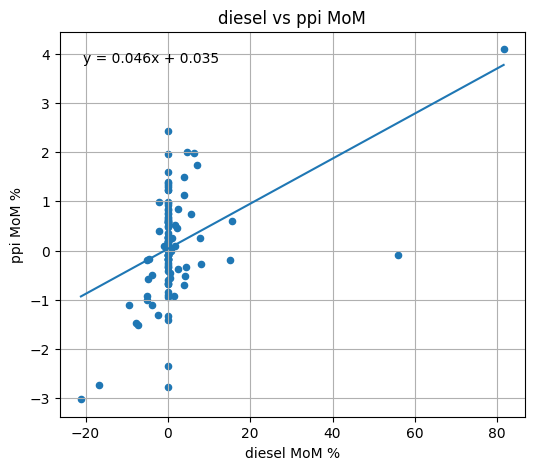

In [36]:
import numpy as np
import matplotlib.pyplot as plt

keys = ["diesel", "ppi"]

# keep only valid x/y rows
data = plot_df[keys].dropna()

x = data[keys[0]]
y = data[keys[1]]

# best-fit line: y = m*x + b
m, b = np.polyfit(x, y, 1)

ax = data.plot.scatter(
    x=keys[0],
    y=keys[1],
    figsize=(6, 5)
)

# draw best-fit line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b

ax.plot(x_line, y_line)

ax.set_title(f"{keys[0]} vs {keys[1]} MoM")
ax.set_xlabel(f"{keys[0]} MoM %")
ax.set_ylabel(f"{keys[1]} MoM %")
ax.grid(True)

# optional equation text
ax.text(
    0.05, 0.95,
    f"y = {m:.3f}x + {b:.3f}",
    transform=ax.transAxes,
    verticalalignment="top"
)

plt.show()

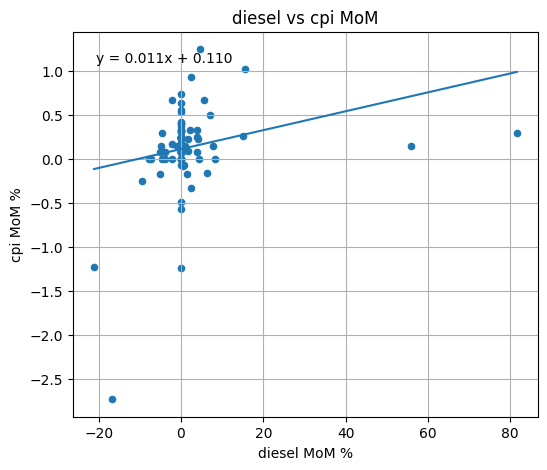

In [37]:
import numpy as np
import matplotlib.pyplot as plt

keys = ["diesel", "cpi"]

# keep only valid x/y rows
data = plot_df[keys].dropna()

x = data[keys[0]]
y = data[keys[1]]

# best-fit line: y = m*x + b
m, b = np.polyfit(x, y, 1)

ax = data.plot.scatter(
    x=keys[0],
    y=keys[1],
    figsize=(6, 5)
)

# draw best-fit line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b

ax.plot(x_line, y_line)

ax.set_title(f"{keys[0]} vs {keys[1]} MoM")
ax.set_xlabel(f"{keys[0]} MoM %")
ax.set_ylabel(f"{keys[1]} MoM %")
ax.grid(True)

# optional equation text
ax.text(
    0.05, 0.95,
    f"y = {m:.3f}x + {b:.3f}",
    transform=ax.transAxes,
    verticalalignment="top"
)

plt.show()